<a href="https://colab.research.google.com/github/Ritik-code10/Data-visualization-/blob/main/EDA_DataViz_UrbanMart_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization & Exploratory Data Analysis (EDA)
## Business Case Study: Retail Superstore Sales Analysis

This notebook is a complete, hands-on guide to **Exploratory Data Analysis (EDA)** and **Data Visualization** using **Matplotlib** and **Seaborn**.

### Business Context
You are a Data Analyst at **"UrbanMart"**, a retail chain selling Furniture, Office Supplies, and Technology products across multiple US regions. Management wants to understand:
- Which products/categories drive the most sales and profit
- Which regions/segments are underperforming
- How discounts affect profitability
- Seasonal/time-based sales trends
- Relationships between sales, profit, quantity, and discount

### What this notebook covers
1. Data Loading & Inspection
2. Data Cleaning & Preprocessing
3. Univariate Analysis (Numerical & Categorical)
4. Bivariate Analysis
5. Multivariate Analysis
6. Time Series / Trend Analysis
7. Outlier Detection
8. Correlation Analysis
9. Distribution Analysis
10. Business Insights & Recommendations


## 1. Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")
print(f"Pandas: {pd.__version__}, Seaborn: {sns.__version__}")

Libraries imported successfully!
Pandas: 2.2.2, Seaborn: 0.13.2


## 2. Creating the Dataset (Synthetic UrbanMart Sales Data)

For this case study, we generate a realistic synthetic dataset that mimics a retail superstore's sales records — similar in structure to the famous "Superstore" dataset. This allows the notebook to run end-to-end without external file dependencies.

In [ ]:
np.random.seed(42)

n = 2000

regions = ['East', 'West', 'Central', 'South']
segments = ['Consumer', 'Corporate', 'Home Office']
categories = ['Furniture', 'Office Supplies', 'Technology']
sub_category_map = {
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Binders', 'Paper', 'Storage', 'Art', 'Labels'],
    'Technology': ['Phones', 'Machines', 'Accessories', 'Copiers']
}
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
order_dates = np.random.choice(dates, size=n)

data = []
for i in range(n):
    category = np.random.choice(categories, p=[0.25, 0.45, 0.30])
    sub_category = np.random.choice(sub_category_map[category])
    region = np.random.choice(regions)
    segment = np.random.choice(segments, p=[0.5, 0.3, 0.2])
    ship_mode = np.random.choice(ship_modes, p=[0.6, 0.2, 0.15, 0.05])

    # Base price varies by category
    base_price = {'Furniture': 250, 'Office Supplies': 40, 'Technology': 400}[category]
    quantity = np.random.randint(1, 10)
    discount = np.random.choice([0, 0.1, 0.2, 0.3, 0.4, 0.5], p=[0.35, 0.25, 0.15, 0.1, 0.1, 0.05])

    sales = round(base_price * quantity * (1 - discount/2) * np.random.uniform(0.8, 1.2), 2)

    # Profit margin depends on category & discount (high discount can cause losses)
    margin = np.random.uniform(0.1, 0.35) - discount * 0.6
    profit = round(sales * margin, 2)

    data.append([i+1, order_dates[i], region, segment, category, sub_category,
                  ship_mode, sales, quantity, discount, profit])

df = pd.DataFrame(data, columns=['Order_ID', 'Order_Date', 'Region', 'Segment',
                                   'Category', 'Sub_Category', 'Ship_Mode',
                                   'Sales', 'Quantity', 'Discount', 'Profit'])

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Introduce some missing values and a duplicate to simulate real data issues
df.loc[np.random.choice(df.index, 20, replace=False), 'Profit'] = np.nan
df.loc[np.random.choice(df.index, 10, replace=False), 'Ship_Mode'] = np.nan
df = pd.concat([df, df.iloc[[5, 10]]], ignore_index=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2002, 11)


,Order_ID,Order_Date,Region,Segment,Category,Sub_Category,Ship_Mode,Sales,Quantity,Discount,Profit
0,1,2023-05-11,East,Corporate,Technology,Accessories,Standard Class,2452.26,6,0.1,633.49
1,2,2023-11-11,Central,Consumer,Office Supplies,Labels,Standard Class,348.99,8,0.0,121.43
2,3,2021-05-02,South,Home Office,Furniture,Furnishings,Standard Class,1177.19,5,0.2,31.79
3,4,2022-04-12,East,Corporate,Office Supplies,Labels,Standard Class,164.10,6,0.3,17.62
4,5,2021-11-27,Central,Corporate,Technology,Copiers,First Class,2301.18,6,0.4,-110.28


## 3. Initial Data Inspection

The first step in EDA is always to understand the **structure, size, types, and quality** of the data.

In [ ]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      2002 non-null   int64         
 1   Order_Date    2002 non-null   datetime64[us]
 2   Region        2002 non-null   str           
 3   Segment       2002 non-null   str           
 4   Category      2002 non-null   str           
 5   Sub_Category  2002 non-null   str           
 6   Ship_Mode     1992 non-null   str           
 7   Sales         2002 non-null   float64       
 8   Quantity      2002 non-null   int64         
 9   Discount      2002 non-null   float64       
 10  Profit        1982 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 172.2 KB


In [ ]:
# Statistical summary of numerical columns
df.describe()

,Order_ID,Order_Date,Sales,Quantity,Discount,Profit
count,2002.000000,2002,2002.000000,2002.000000,2002.000000,1982.000000
mean,999.508991,2022-07-11 22:22:10.669330,952.936054,4.976523,0.146104,142.470610
min,1.000000,2021-01-01 00:00:00,25.820000,1.000000,0.000000,-374.630000
25%,499.250000,2021-10-11 06:00:00,200.215000,3.000000,0.000000,12.057500
50%,999.500000,2022-07-26 00:00:00,429.895000,5.000000,0.100000,51.920000
75%,1499.750000,2023-04-11 00:00:00,1612.145000,7.000000,0.200000,209.680000
max,2000.000000,2023-12-30 00:00:00,4278.560000,9.000000,0.500000,1415.570000
std,578.056453,NaN,972.436808,2.545527,0.152629,215.391483


In [ ]:
# Statistical summary of categorical columns
df.describe(include='object')

/tmp/ipykernel_586/2864362938.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Region,Segment,Category,Sub_Category,Ship_Mode
count,2002,2002,2002,2002,1992
unique,4,3,3,13,4
top,Central,Consumer,Office Supplies,Art,Standard Class
freq,504,999,879,209,1203


In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Order_ID         0
Order_Date       0
Region           0
Segment          0
Category         0
Sub_Category     0
Ship_Mode       10
Sales            0
Quantity         0
Discount         0
Profit          20
dtype: int64


In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 2


## 4. Data Cleaning & Preprocessing

Before visualizing, we handle:
- Duplicate records
- Missing values (impute or drop based on business logic)
- Feature engineering (extracting Year, Month, Quarter from dates; creating Profit Margin)

In [ ]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# Handle missing Profit -> impute with median profit of that Category (business-logical imputation)
df['Profit'] = df.groupby('Category')['Profit'].transform(lambda x: x.fillna(x.median()))

# Handle missing Ship_Mode -> fill with mode (most common shipping mode)
df['Ship_Mode'] = df['Ship_Mode'].fillna(df['Ship_Mode'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Shape after removing duplicates: (2000, 11)
Missing values after cleaning:
Order_ID        0
Order_Date      0
Region          0
Segment         0
Category        0
Sub_Category    0
Ship_Mode       0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [ ]:
# Feature Engineering: extract date-based features
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Month_Name'] = df['Order_Date'].dt.month_name()
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Order_Weekday'] = df['Order_Date'].dt.day_name()

# Profit Margin (%)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

df.head()

,Order_ID,Order_Date,Region,Segment,Category,Sub_Category,Ship_Mode,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Month_Name,Order_Quarter,Order_Weekday,Profit_Margin
0,1,2023-05-11,East,Corporate,Technology,Accessories,Standard Class,2452.26,6,0.1,633.49,2023,5,May,2,Thursday,25.832905
1,2,2023-11-11,Central,Consumer,Office Supplies,Labels,Standard Class,348.99,8,0.0,121.43,2023,11,November,4,Saturday,34.794693
2,3,2021-05-02,South,Home Office,Furniture,Furnishings,Standard Class,1177.19,5,0.2,31.79,2021,5,May,2,Sunday,2.700499
3,4,2022-04-12,East,Corporate,Office Supplies,Labels,Standard Class,164.10,6,0.3,17.62,2022,4,April,2,Tuesday,10.737355
4,5,2021-11-27,Central,Corporate,Technology,Copiers,First Class,2301.18,6,0.4,-110.28,2021,11,November,4,Saturday,-4.792324


## 5. Univariate Analysis — Numerical Variables

Univariate analysis examines **one variable at a time** to understand its distribution, central tendency, and spread.

### 5.1 Histograms — Distribution of Sales, Profit, Discount, Quantity

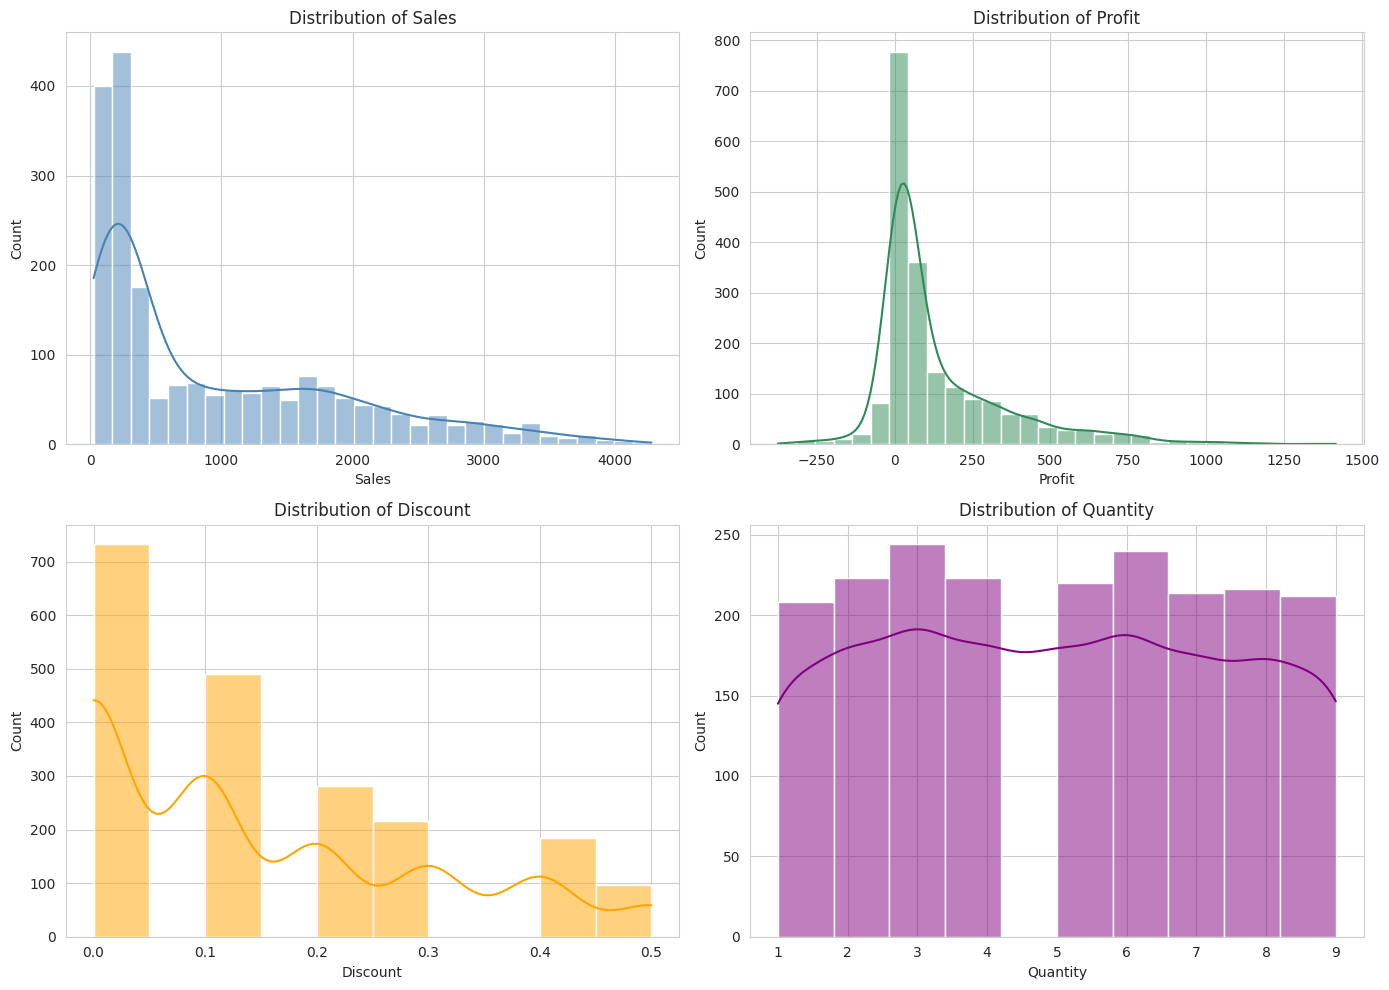

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Sales')

sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Distribution of Profit')

sns.histplot(df['Discount'], bins=10, kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Distribution of Discount')

sns.histplot(df['Quantity'], bins=10, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Distribution of Quantity')

plt.tight_layout()
plt.show()

**Insight:** Sales and Profit are right-skewed — most orders generate modest revenue/profit, but a few large orders pull the distribution to the right. Discounts are concentrated at 0% and 10%.

### 5.2 Box Plots — Spotting Spread and Outliers

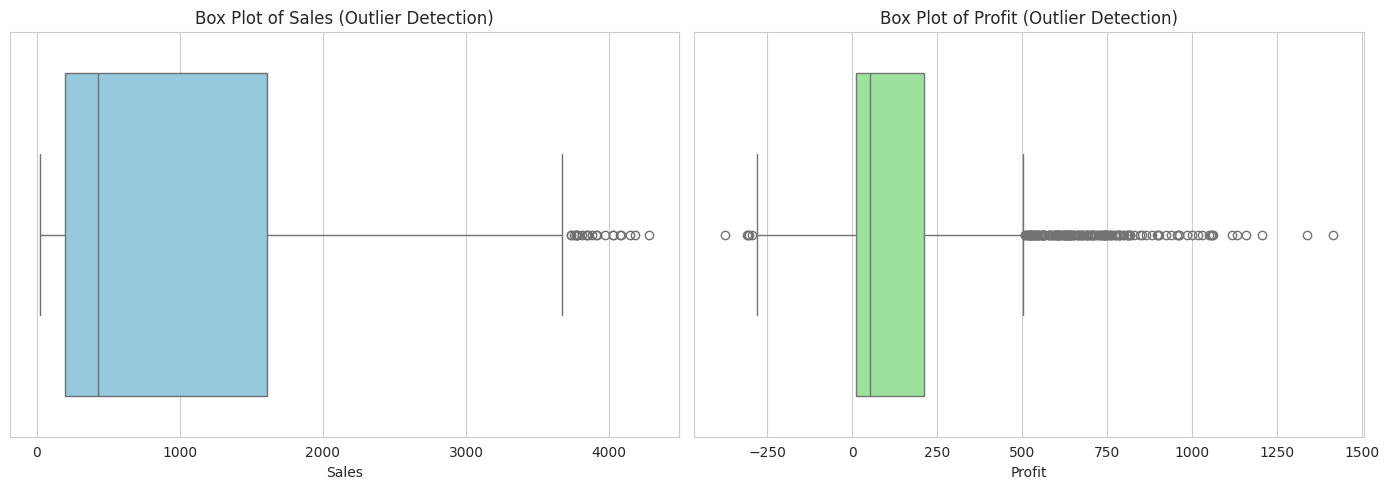

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot of Sales (Outlier Detection)')

sns.boxplot(x=df['Profit'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot of Profit (Outlier Detection)')

plt.tight_layout()
plt.show()

## 6. Univariate Analysis — Categorical Variables

### 6.1 Count Plots — Frequency of Categories

/tmp/ipykernel_586/4120754560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', ax=axes[0,0], palette='viridis',
/tmp/ipykernel_586/4120754560.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', ax=axes[0,1], palette='magma',
/tmp/ipykernel_586/4120754560.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment', ax=axes[1,0], palette='crest',
/tmp/ipykernel_586/4120754560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

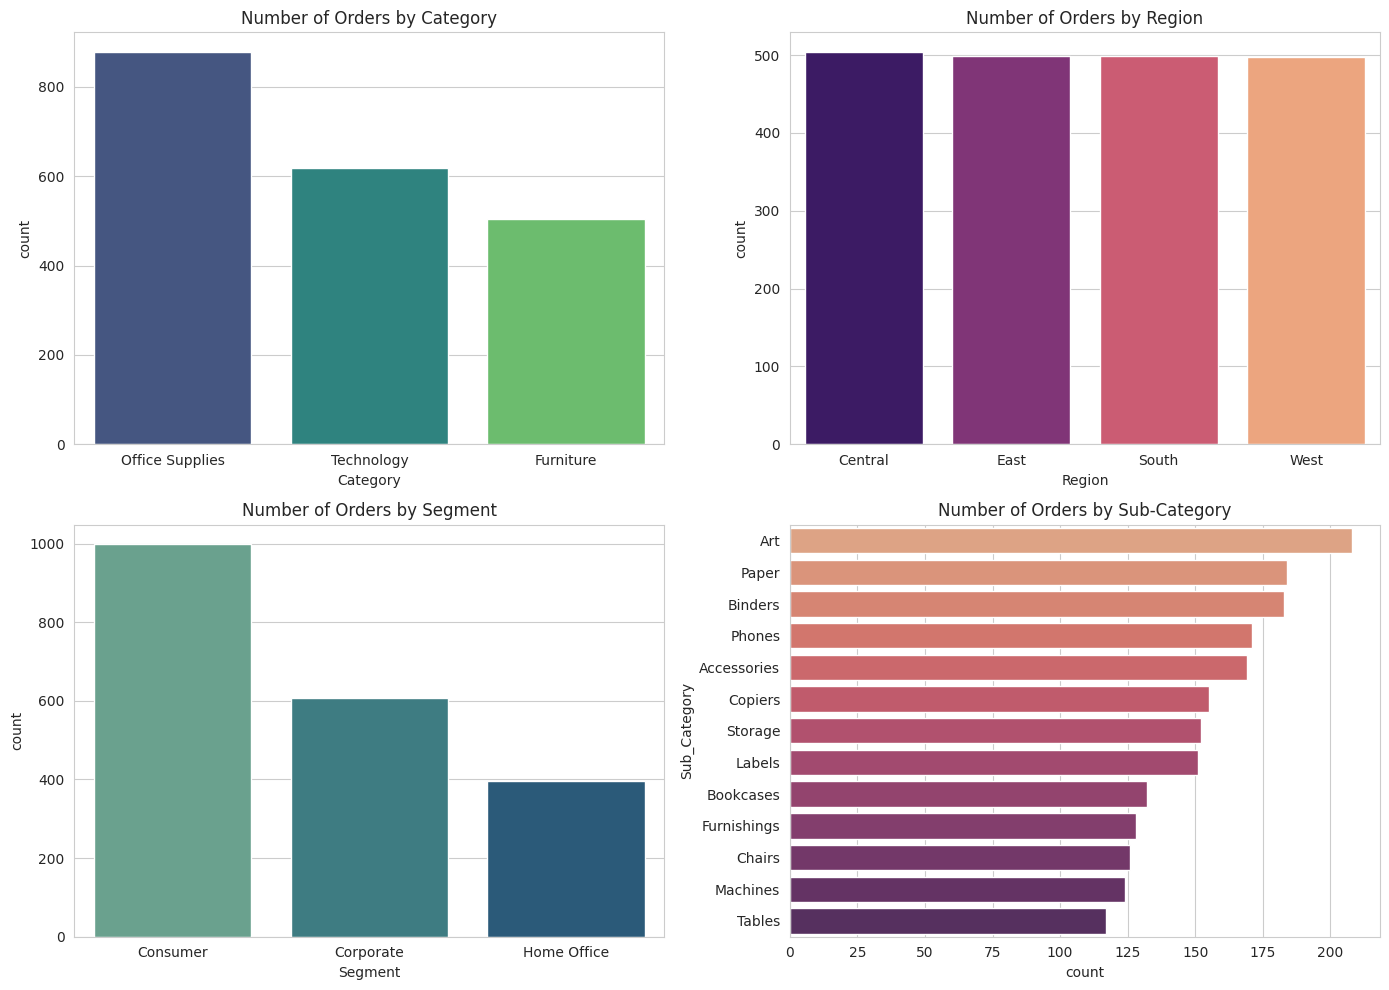

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Category', ax=axes[0,0], palette='viridis',
              order=df['Category'].value_counts().index)
axes[0,0].set_title('Number of Orders by Category')

sns.countplot(data=df, x='Region', ax=axes[0,1], palette='magma',
              order=df['Region'].value_counts().index)
axes[0,1].set_title('Number of Orders by Region')

sns.countplot(data=df, x='Segment', ax=axes[1,0], palette='crest',
              order=df['Segment'].value_counts().index)
axes[1,0].set_title('Number of Orders by Segment')

sns.countplot(data=df, y='Sub_Category', ax=axes[1,1], palette='flare',
              order=df['Sub_Category'].value_counts().index)
axes[1,1].set_title('Number of Orders by Sub-Category')

plt.tight_layout()
plt.show()

### 6.2 Pie Chart — Market Share by Category (Matplotlib)

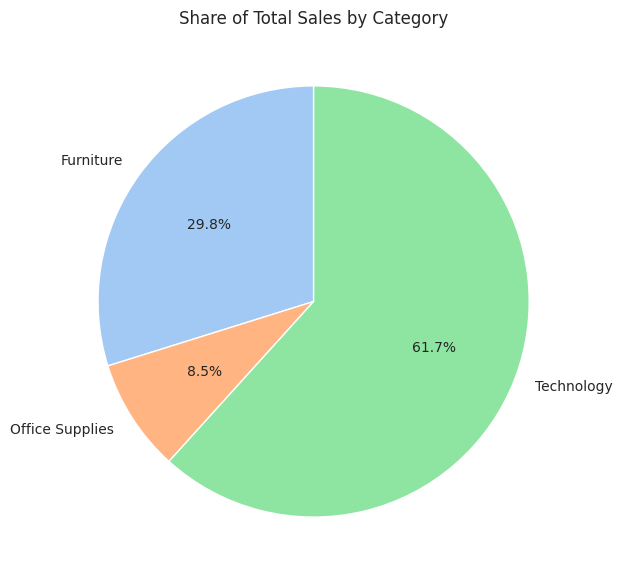

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90,
        wedgeprops={'edgecolor': 'white'})
plt.title('Share of Total Sales by Category')
plt.show()

## 7. Bivariate Analysis

Bivariate analysis explores the **relationship between two variables** — critical for understanding what drives sales and profit.

### 7.1 Bar Plot — Average Sales & Profit by Category

/tmp/ipykernel_1196/1533278933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='Sales', estimator=np.sum, ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1196/1533278933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='Profit', estimator=np.sum, ax=axes[1], palette='Greens_d')


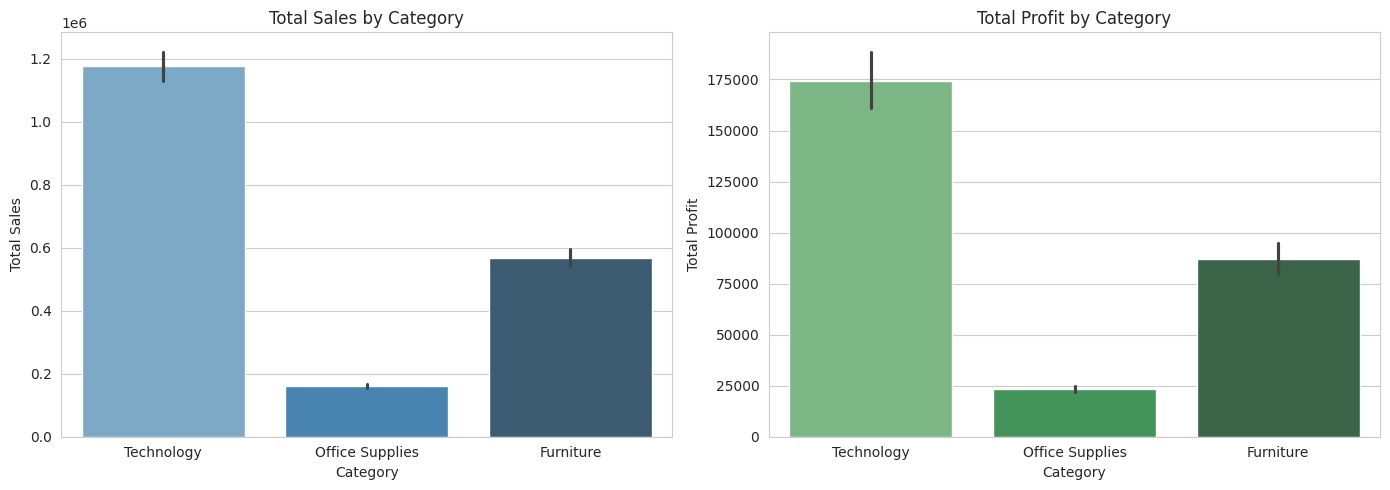

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Category', y='Sales', estimator=np.sum, ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Total Sales')

sns.barplot(data=df, x='Category', y='Profit', estimator=np.sum, ax=axes[1], palette='Greens_d')
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

**Insight:** Technology drives the highest sales and profit, while Furniture — despite decent sales — may have thinner margins (validated further below).

### 7.2 Scatter Plot — Sales vs Profit (with Discount as Hue)

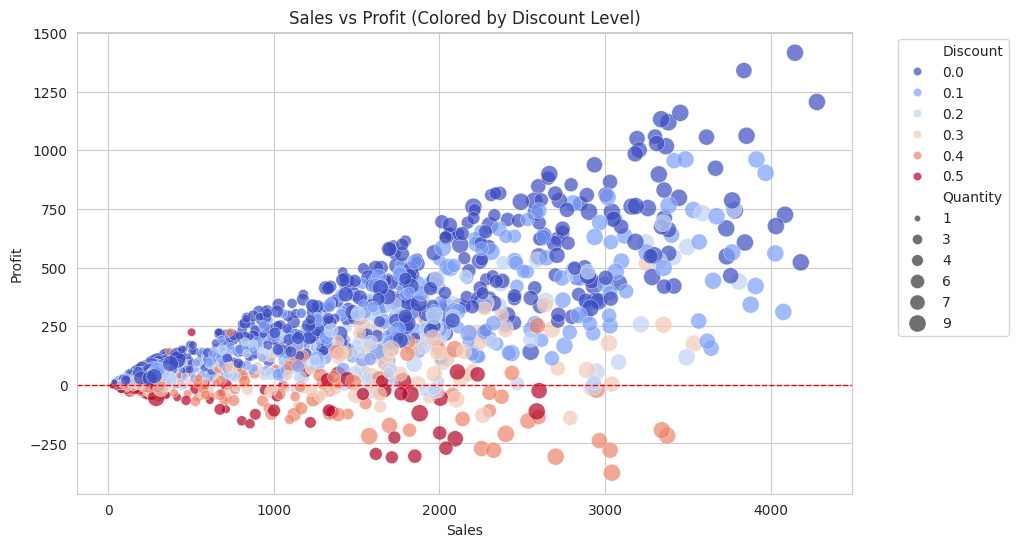

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Discount', size='Quantity',
                 palette='coolwarm', alpha=0.7, sizes=(20, 150))
plt.title('Sales vs Profit (Colored by Discount Level)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Insight:** Orders with higher discounts (lighter/red points) cluster near or below the zero-profit line — confirming that **heavy discounting erodes profitability**.

### 7.3 Box Plot — Profit Margin by Discount Level

/tmp/ipykernel_586/3557353506.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Discount', y='Profit_Margin', palette='Set2')


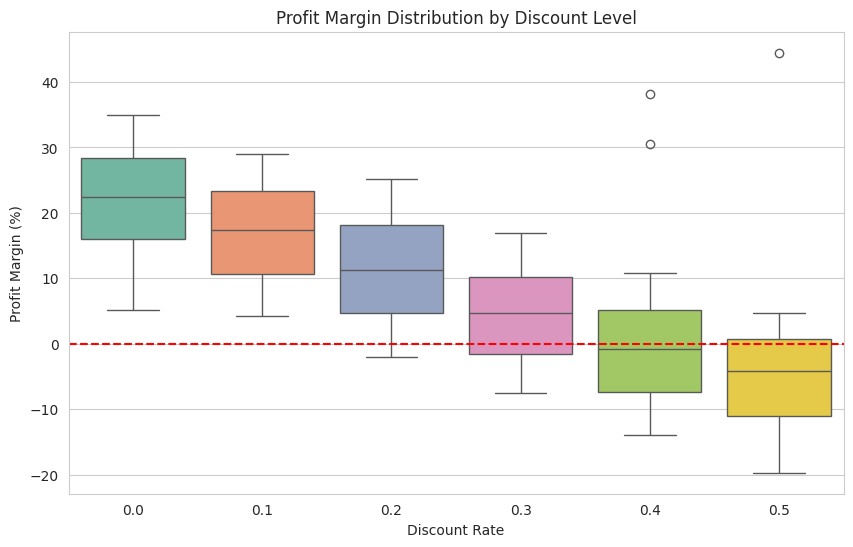

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Discount', y='Profit_Margin', palette='Set2')
plt.title('Profit Margin Distribution by Discount Level')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin (%)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

### 7.4 Line Plot — Sales Trend Over Time

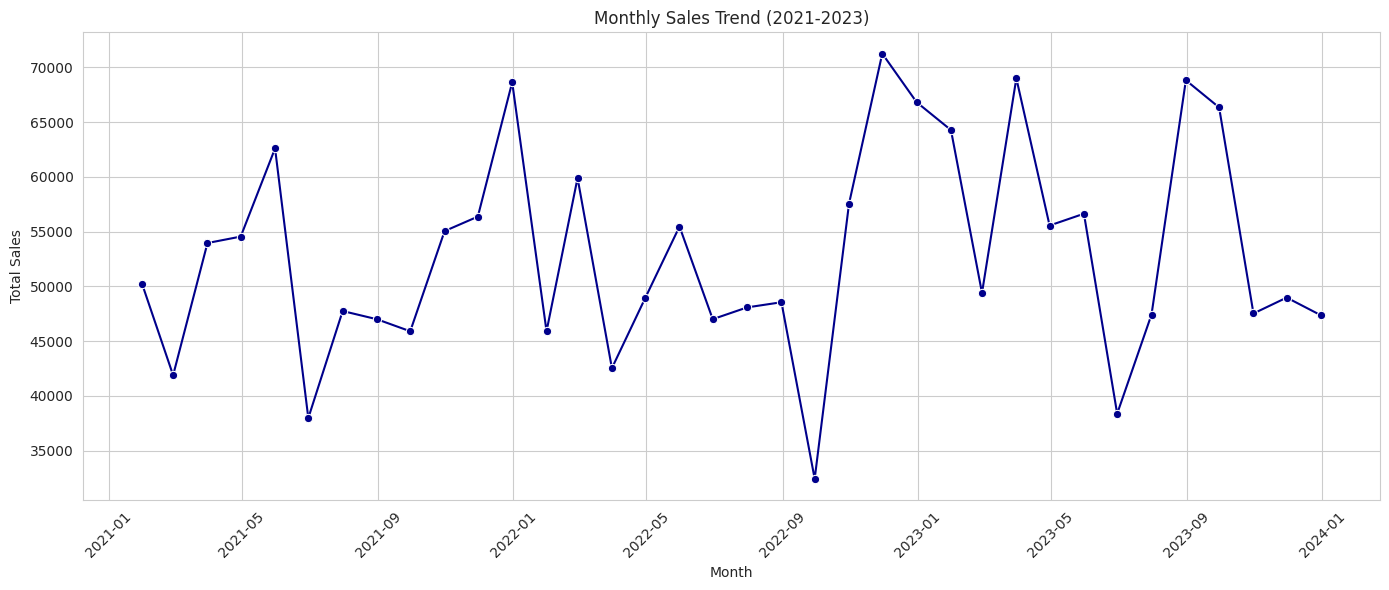

In [ ]:
monthly_sales = df.groupby(pd.Grouper(key='Order_Date', freq='ME'))['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Order_Date', y='Sales', marker='o', color='darkblue')
plt.title('Monthly Sales Trend (2021-2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Multivariate Analysis

Multivariate analysis examines relationships among **three or more variables** simultaneously.

### 8.1 Grouped Bar Plot — Sales by Category and Region

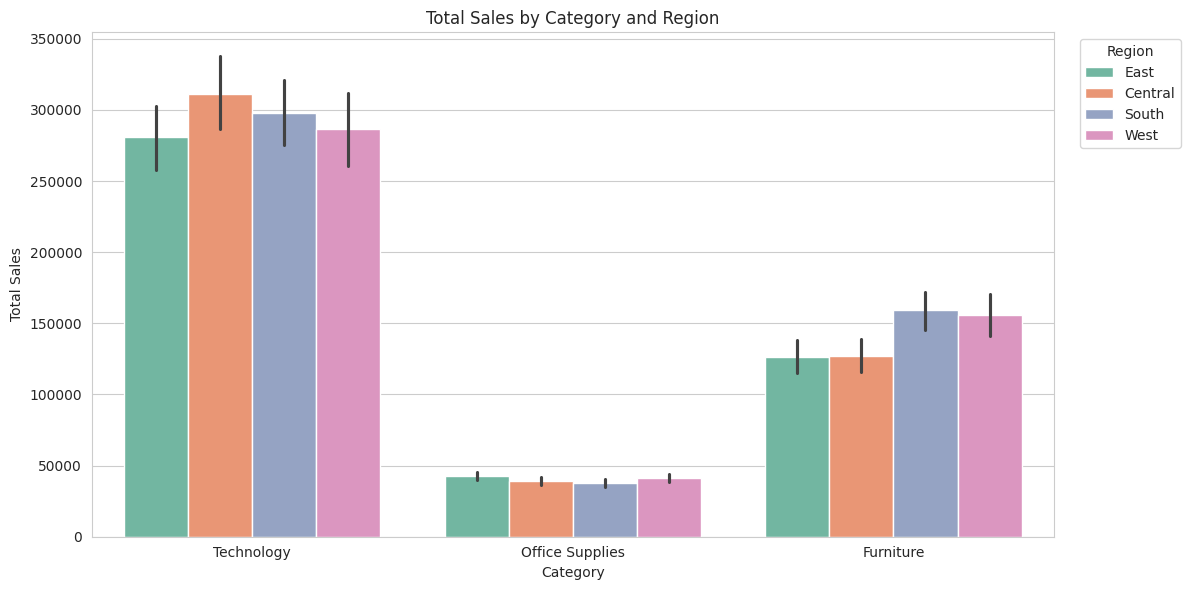

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Category', y='Sales', hue='Region', estimator=np.sum, palette='Set2')
plt.title('Total Sales by Category and Region')
plt.ylabel('Total Sales')
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8.2 Heatmap — Average Profit Margin by Category and Segment

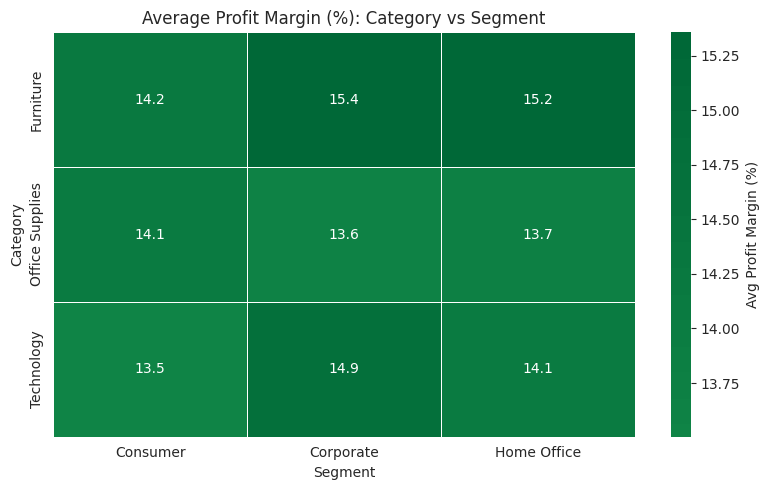

In [ ]:
pivot_table = df.pivot_table(values='Profit_Margin', index='Category',
                               columns='Segment', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Avg Profit Margin (%)'})
plt.title('Average Profit Margin (%): Category vs Segment')
plt.tight_layout()
plt.show()

### 8.3 Pair Plot — Relationships Between Numerical Variables

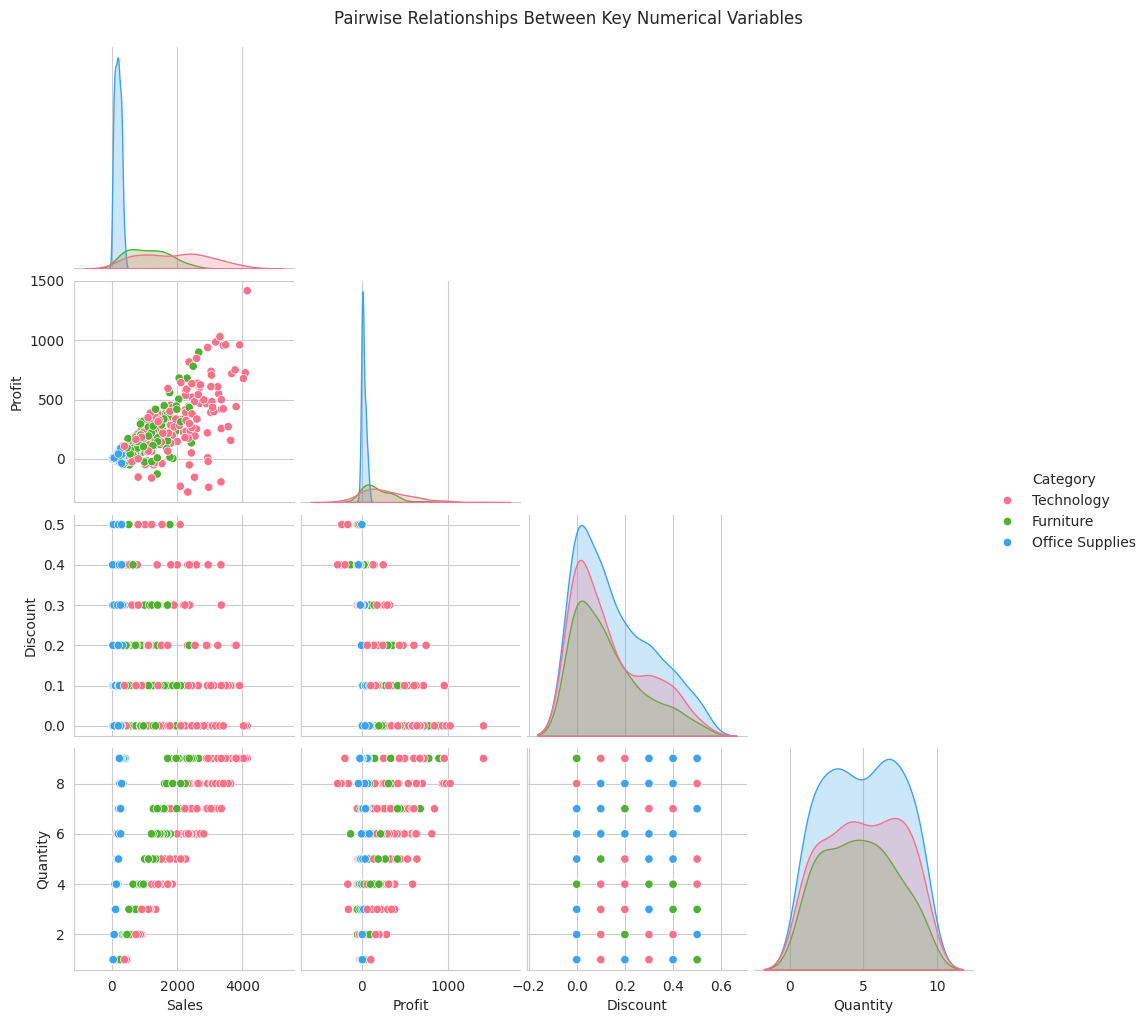

In [ ]:
sample_df = df.sample(500, random_state=1)  # sample for clearer visuals
sns.pairplot(sample_df[['Sales', 'Profit', 'Discount', 'Quantity', 'Category']],
             hue='Category', palette='husl', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships Between Key Numerical Variables', y=1.02)
plt.show()

### 8.4 Facet Grid — Sales Distribution by Category Across Regions

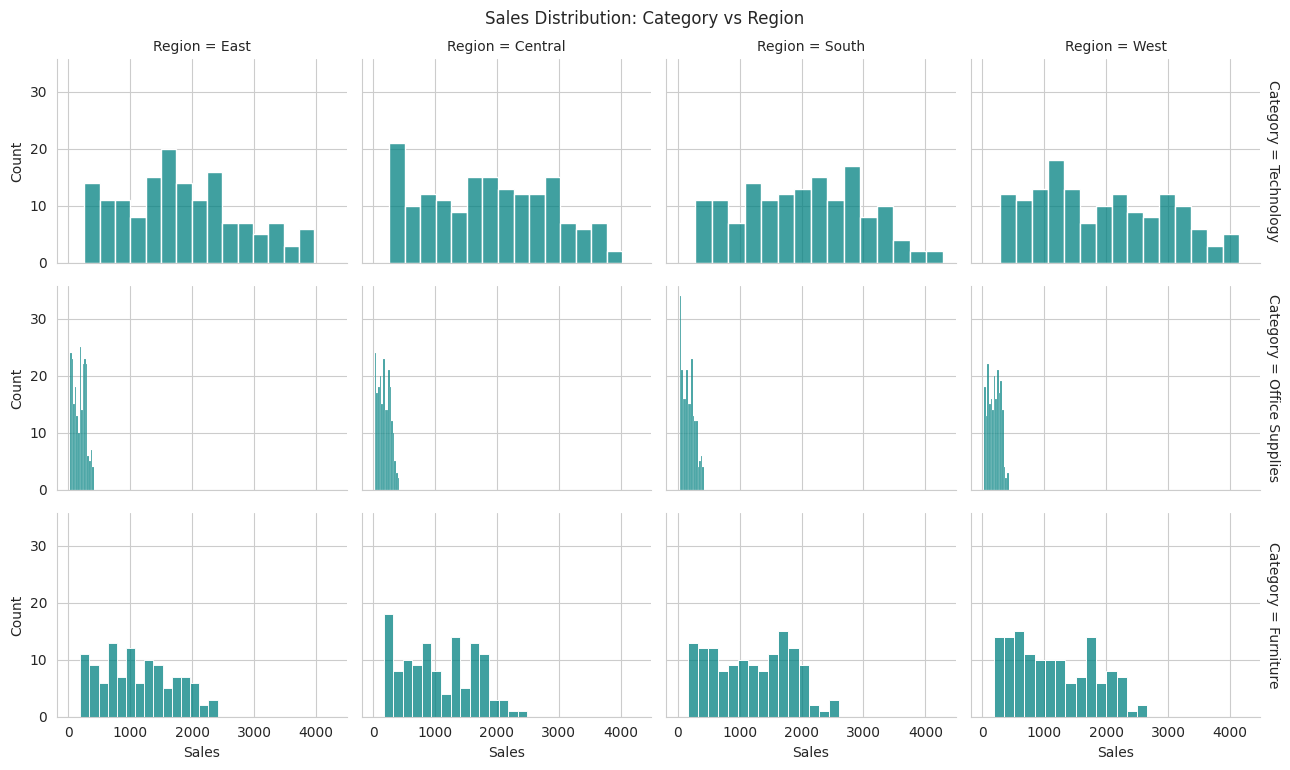

In [ ]:
g = sns.FacetGrid(df, col='Region', row='Category', height=2.5, aspect=1.3, margin_titles=True)
g.map(sns.histplot, 'Sales', bins=15, color='teal')
g.fig.suptitle('Sales Distribution: Category vs Region', y=1.02)
plt.show()

## 9. Correlation Analysis

Understanding linear relationships between numerical variables helps identify which factors are most associated with profit.

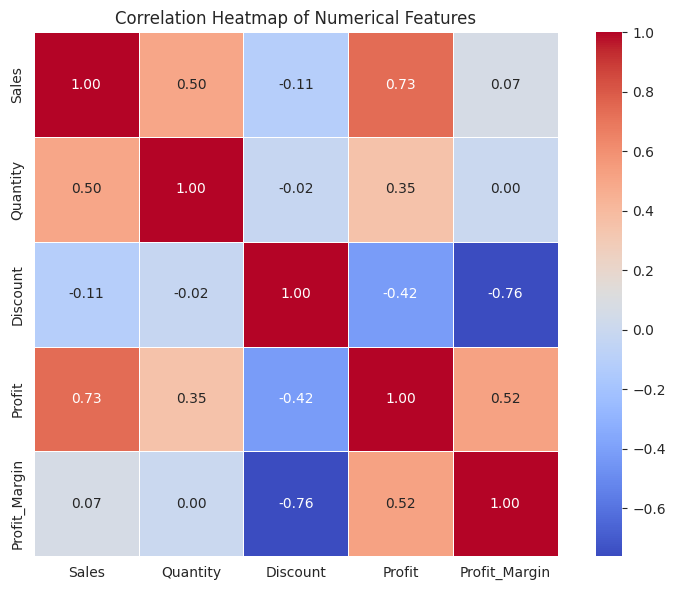

In [ ]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Insight:** Discount shows a notable negative correlation with Profit Margin — a key actionable finding for pricing strategy.

## 10. Outlier Detection (IQR Method)

Outliers can represent either data errors or genuinely important high-value/low-value transactions (e.g., bulk orders or major losses). We detect them using the Interquartile Range (IQR) method.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

sales_outliers, low_s, up_s = detect_outliers_iqr(df, 'Sales')
profit_outliers, low_p, up_p = detect_outliers_iqr(df, 'Profit')

print(f"Sales outlier bounds: ({low_s:.2f}, {up_s:.2f}) -> {len(sales_outliers)} outliers")
print(f"Profit outlier bounds: ({low_p:.2f}, {up_p:.2f}) -> {len(profit_outliers)} outliers")

Sales outlier bounds: (-1915.75, 3727.49) -> 22 outliers
Profit outlier bounds: (-285.12, 507.84) -> 159 outliers


/tmp/ipykernel_586/2504275836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Sales', x='Category', ax=axes[0], palette='Set3')
/tmp/ipykernel_586/2504275836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Profit', x='Category', ax=axes[1], palette='Set3')


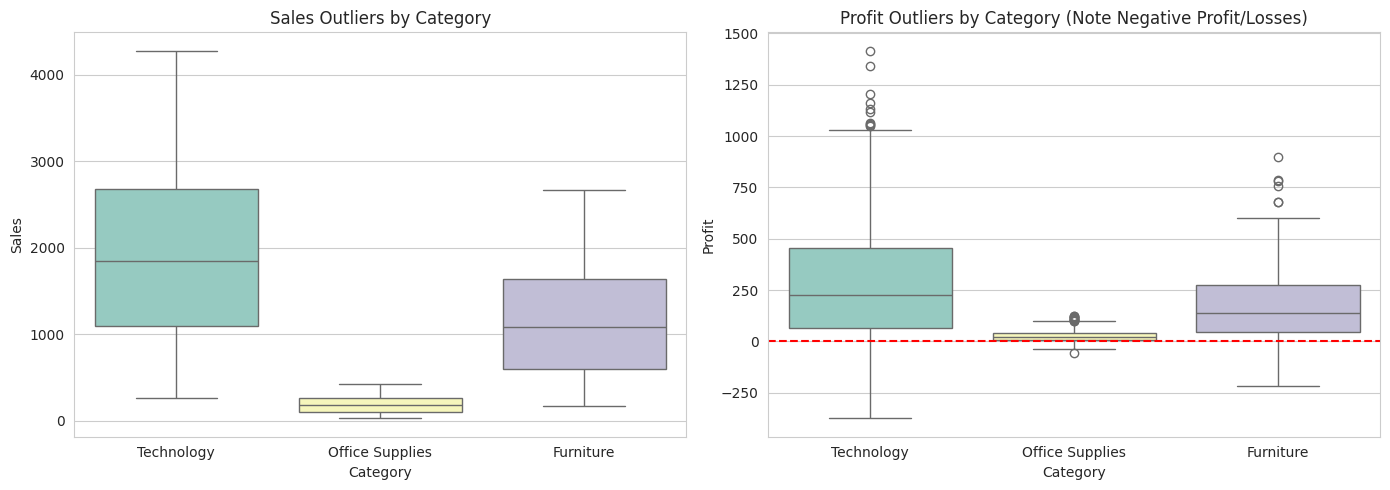

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, y='Sales', x='Category', ax=axes[0], palette='Set3')
axes[0].set_title('Sales Outliers by Category')

sns.boxplot(data=df, y='Profit', x='Category', ax=axes[1], palette='Set3')
axes[1].set_title('Profit Outliers by Category (Note Negative Profit/Losses)')
axes[1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 11. Time-Based / Seasonal Analysis

### 11.1 Quarterly Sales & Profit Trends

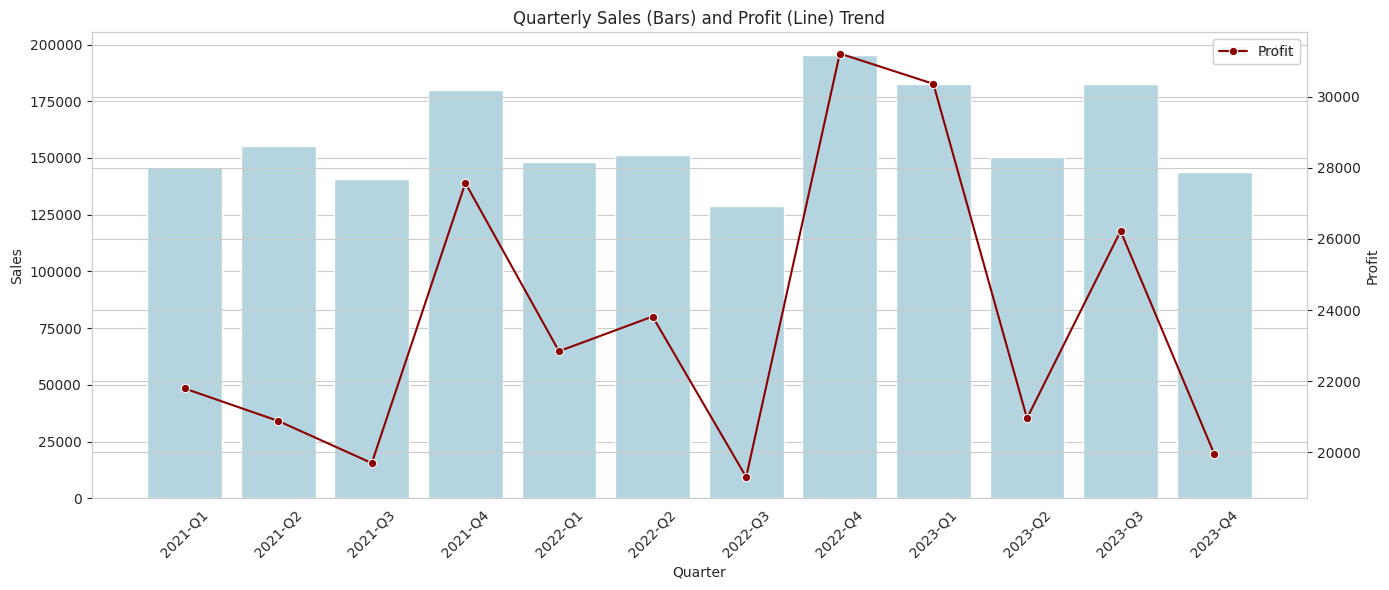

In [ ]:
quarterly = df.groupby(['Order_Year', 'Order_Quarter']).agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
quarterly['Period'] = quarterly['Order_Year'].astype(str) + '-Q' + quarterly['Order_Quarter'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(data=quarterly, x='Period', y='Sales', color='lightblue', ax=ax1, label='Sales')
ax1.set_ylabel('Sales')
ax1.set_xlabel('Quarter')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=quarterly, x='Period', y='Profit', color='darkred', marker='o', ax=ax2, label='Profit')
ax2.set_ylabel('Profit')

plt.title('Quarterly Sales (Bars) and Profit (Line) Trend')
fig.tight_layout()
plt.show()

### 11.2 Sales by Day of Week (Seasonality Check)

/tmp/ipykernel_586/3546567926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='cubehelix')


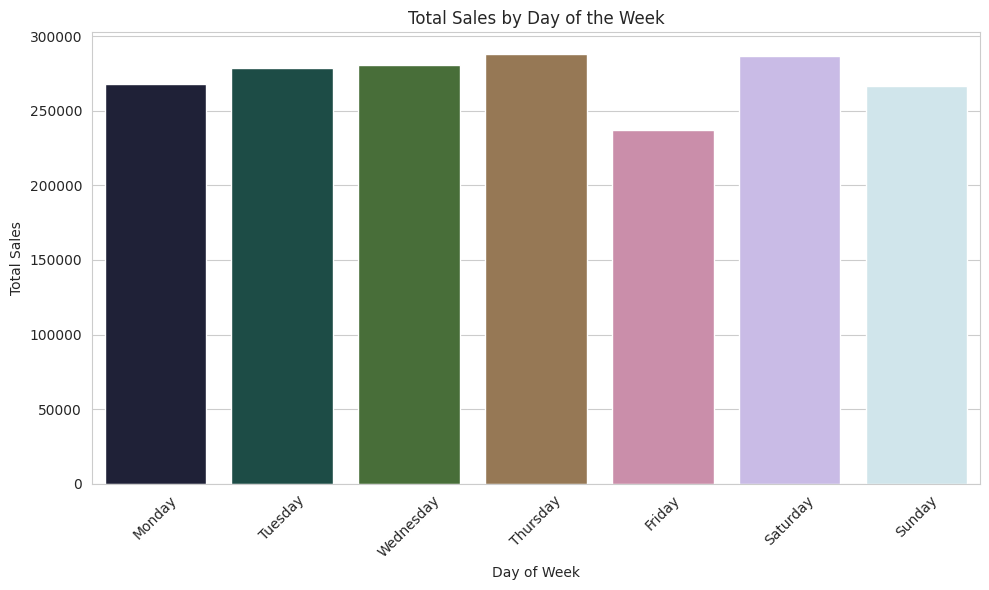

In [ ]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('Order_Weekday')['Sales'].sum().reindex(weekday_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='cubehelix')
plt.title('Total Sales by Day of the Week')
plt.ylabel('Total Sales')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Advanced Visualizations

### 12.1 Violin Plot — Sales Distribution by Ship Mode

/tmp/ipykernel_586/1080690638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Ship_Mode', y='Sales', palette='Pastel1', inner='quartile')


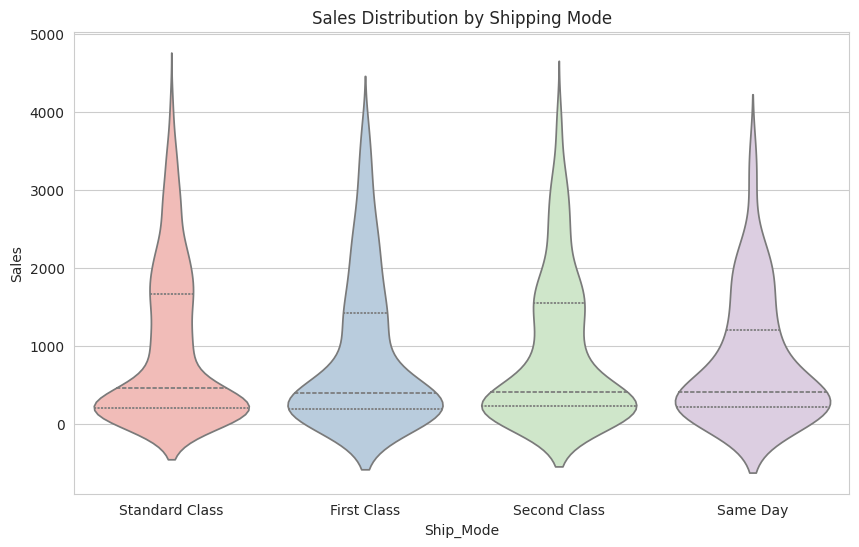

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Ship_Mode', y='Sales', palette='Pastel1', inner='quartile')
plt.title('Sales Distribution by Shipping Mode')
plt.show()

### 12.2 Joint Plot — Sales vs Profit with Distribution

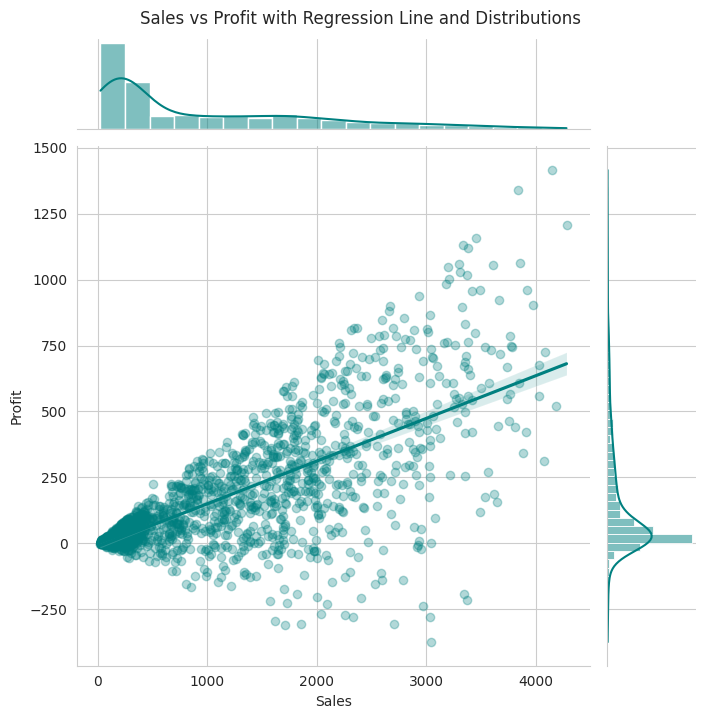

In [ ]:
sns.jointplot(data=df, x='Sales', y='Profit', kind='reg', height=7,
              joint_kws={'scatter_kws': {'alpha':0.3}}, color='teal')
plt.suptitle('Sales vs Profit with Regression Line and Distributions', y=1.02)
plt.show()

### 12.3 Stacked Bar Chart — Segment Composition within Each Region

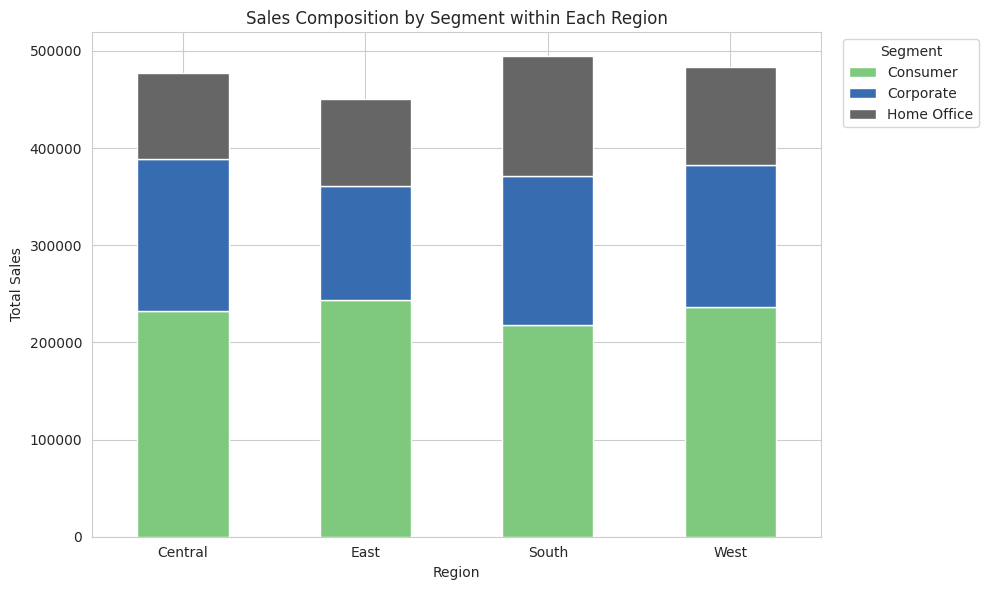

In [ ]:
segment_region = df.groupby(['Region', 'Segment'])['Sales'].sum().unstack()

segment_region.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Accent')
plt.title('Sales Composition by Segment within Each Region')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 12.4 Top Sub-Categories by Profit (Horizontal Bar)

/tmp/ipykernel_586/2846686476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette=colors)


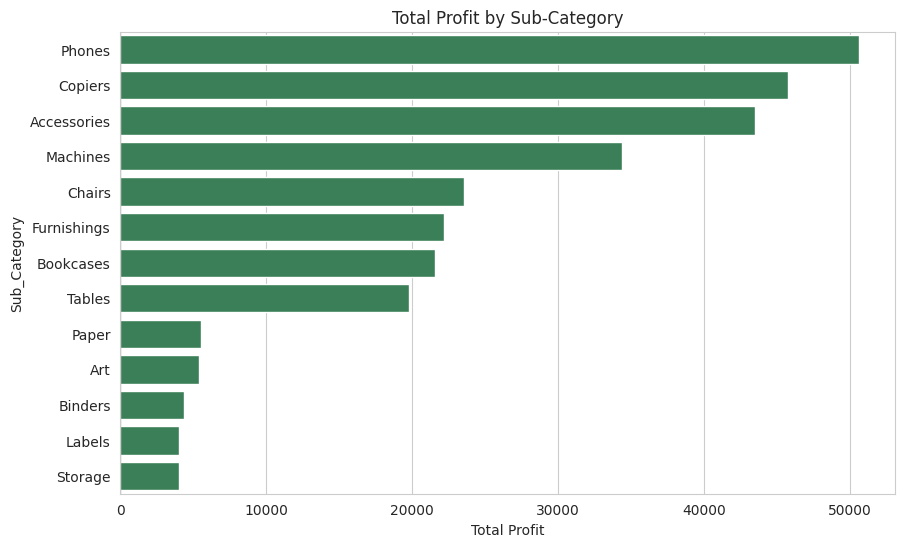

In [ ]:
subcat_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['seagreen' if x > 0 else 'crimson' for x in subcat_profit.values]
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## 13. Business Insights & Recommendations

Based on the complete EDA and visualization performed above, here are the key takeaways for UrbanMart's management:

1. **Technology leads in sales and profit** — continue prioritizing inventory and marketing investment in this category.
2. **Discounts above 20% strongly correlate with reduced or negative profit margins** — the discount policy should be capped or restructured, especially for Furniture sub-categories like Tables and Bookcases which show frequent losses.
3. **Sales show clear seasonality**, with certain quarters consistently outperforming others — inventory planning and promotional campaigns should align with these peaks.
4. **Regional disparities exist** — some regions show high sales volume but lower profit margins, suggesting a need for region-specific pricing or cost-structure review.
5. **Corporate and Home Office segments**, while smaller in volume, often show healthier margins than Consumer — a potential area for targeted B2B growth strategies.
6. **Outlier orders** (very high sales or large losses) should be reviewed individually — they may represent bulk-order opportunities or pricing errors that need correction.

### EDA Techniques Demonstrated in This Notebook
| Technique | Purpose | Visualization Used |
|---|---|---|
| Data Inspection | Understand structure & types | `.info()`, `.describe()` |
| Missing Value Treatment | Data quality | `.isnull()`, group-based imputation |
| Univariate (Numerical) | Distribution shape | Histogram, KDE, Box plot |
| Univariate (Categorical) | Frequency analysis | Count plot, Pie chart |
| Bivariate Analysis | Relationship between 2 vars | Bar plot, Scatter plot, Line plot |
| Multivariate Analysis | Relationship among 3+ vars | Grouped bar, Heatmap, Pair plot, Facet grid |
| Correlation Analysis | Linear relationships | Correlation heatmap |
| Outlier Detection | Data quality / extreme values | IQR method + Box plot |
| Time Series Analysis | Trends & seasonality | Line plot, Bar + line combo |
| Advanced Visuals | Deeper distributional insight | Violin plot, Joint plot, Stacked bar |

---
### Next Steps
- Build predictive models (e.g., regression for Sales/Profit forecasting, classification for high-risk discount orders)
- Create an interactive dashboard (Plotly/Dash or Power BI) for real-time monitoring
- Automate this EDA pipeline for monthly reporting
